# Notebook 21 -- Wu 2003 Explicit Control Structures

This notebook verifies the minimal explicit-loop model selected for the Wu 2003
extension. S-A and S-B are now separate closed-loop simulations rather than
measurement projections of one shared trajectory.

- **S-A:** composition-rich structure; reflux and boilup respond to column
  composition information.
- **S-B:** conventional structure; reflux ratio is fixed and the reboiler loop
  regulates the reboiler-temperature proxy.

The goal is not to reproduce every tray hydraulic transient from the source
papers. The goal is to verify the control/information mechanisms needed before
nb22 data generation: snowball, masking, compensation, and S-A/S-B trajectory
separation.


## 1. Imports and channel contracts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.recycle.physics import QJ_NOM, T_SP
from cstr_sbi.recycle.scenarios import SCENARIO_CONFIGS
from cstr_sbi.recycle.simulator import (
    RAW_CHANNELS,
    RAW_INDEX,
    SA_CHANNELS,
    SB_CHANNELS,
    deterministic_window,
)

pd.set_option("display.precision", 5)
print("Raw channels:", RAW_CHANNELS)
print("S-A channels:", SA_CHANNELS)
print("S-B channels:", SB_CHANNELS)


Raw channels: ['z_A', 'T_r', 'T_j', 'Q_j', 'x_D', 'x_B', 'F_R_norm', 'T_reb', 'Q_reb', 'F_B_norm', 'R_norm', 'V_norm']
S-A channels: ['T_r', 'T_j', 'Q_j', 'x_D', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']
S-B channels: ['T_r', 'T_j', 'Q_j', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm', 'R_norm', 'V_norm']


## 2. Scenario subset

In [2]:
SCENARIO_KEYS = ["W1_healthy", "W2_cat_decay", "W3_rxr_fouling", "W4_col_tray_eff"]

scenario_df = pd.DataFrame([
    {
        "key": key,
        "id": SCENARIO_CONFIGS[key].id,
        "alpha": SCENARIO_CONFIGS[key].alpha,
        "beta_r": SCENARIO_CONFIGS[key].beta_r,
        "eta_col": SCENARIO_CONFIGS[key].eta_col,
        "xi_reb": SCENARIO_CONFIGS[key].xi_reb,
        "z_A0_eff": SCENARIO_CONFIGS[key].z_A0_eff,
        "description": SCENARIO_CONFIGS[key].description,
    }
    for key in SCENARIO_KEYS
]).set_index("key")
scenario_df


,id,alpha,beta_r,eta_col,xi_reb,z_A0_eff,description
key,,,,,,,
W1_healthy,1,1.00,1.00,1.0,1.0,0.9,"Healthy plant, all parameters nominal."
W2_cat_decay,2,0.65,1.00,1.0,1.0,0.9,Severe catalyst decay (alpha=0.65). Reaction r...
W3_rxr_fouling,3,1.00,0.65,1.0,1.0,0.9,Severe CSTR jacket fouling (beta_r=0.65). UA r...
W4_col_tray_eff,4,1.00,1.00,0.7,1.0,0.9,Column tray efficiency loss (eta_col=0.70). Se...


## 3. Generate S-A and S-B deterministic trajectories

In [3]:
def run_case(key, structure):
    scenario = SCENARIO_CONFIGS[key]
    t, raw = deterministic_window(scenario, structure=structure, t_final_h=2.0, n_save=120)
    return {"t": t, "raw": raw, "scenario": scenario, "structure": structure}


cases = {}
for key in SCENARIO_KEYS:
    for structure in ["S-A", "S-B"]:
        cases[(key, structure)] = run_case(key, structure)

open_case = run_case("W3_rxr_fouling_ol", "S-B")

print(f"Generated {len(cases)} closed-loop structure trajectories plus one open-loop diagnostic")
print("Example raw shape:", cases[("W1_healthy", "S-A")]["raw"].shape)


Generated 8 closed-loop structure trajectories plus one open-loop diagnostic
Example raw shape: (120, 12)


## 4. Control-structure views

In [4]:
def project(raw, channels):
    return raw[:, [RAW_INDEX[ch] for ch in channels]]


sa_w1 = project(cases[("W1_healthy", "S-A")]["raw"], SA_CHANNELS)
sb_w1 = project(cases[("W1_healthy", "S-B")]["raw"], SB_CHANNELS)

print("S-A W1 shape:", sa_w1.shape)
print("S-B W1 shape:", sb_w1.shape)
display(pd.DataFrame(sa_w1[:5], columns=SA_CHANNELS))
display(pd.DataFrame(sb_w1[:5], columns=SB_CHANNELS))


S-A W1 shape: (120, 10)
S-B W1 shape: (120, 9)


,T_r,T_j,Q_j,x_D,T_reb,Q_reb,F_R_norm,F_B_norm,R_norm,V_norm
0,342.27634,331.37158,9472856.0,0.95,373.28326,13491927.0,1.0544,1.0,0.76665,1.09334
1,342.27634,331.37152,9472856.0,0.95,373.28326,13491928.0,1.0544,1.0,0.76665,1.09334
2,342.27634,331.37158,9472856.0,0.95,373.28326,13491919.0,1.0544,1.0,0.76665,1.09334
3,342.27634,331.37164,9472856.0,0.95,373.28326,13491922.0,1.0544,1.0,0.76665,1.09334
4,342.27634,331.37143,9472856.0,0.95,373.28326,13491933.0,1.0544,1.0,0.76665,1.09334


,T_r,T_j,Q_j,T_reb,Q_reb,F_R_norm,F_B_norm,R_norm,V_norm
0,342.27850,331.35239,9490195.0,372.0,12004584.0,1.00176,1.0,1.0,0.99943
1,342.27850,331.35284,9490195.0,372.0,12004584.0,1.00176,1.0,1.0,0.99943
2,342.27850,331.35315,9490195.0,372.0,12004584.0,1.00176,1.0,1.0,0.99943
3,342.27853,331.35400,9490439.0,372.0,12004584.0,1.00176,1.0,1.0,0.99943
4,342.27859,331.35376,9490928.0,372.0,12004586.0,1.00176,1.0,1.0,0.99943


## 5. W1-W4 trajectory comparison

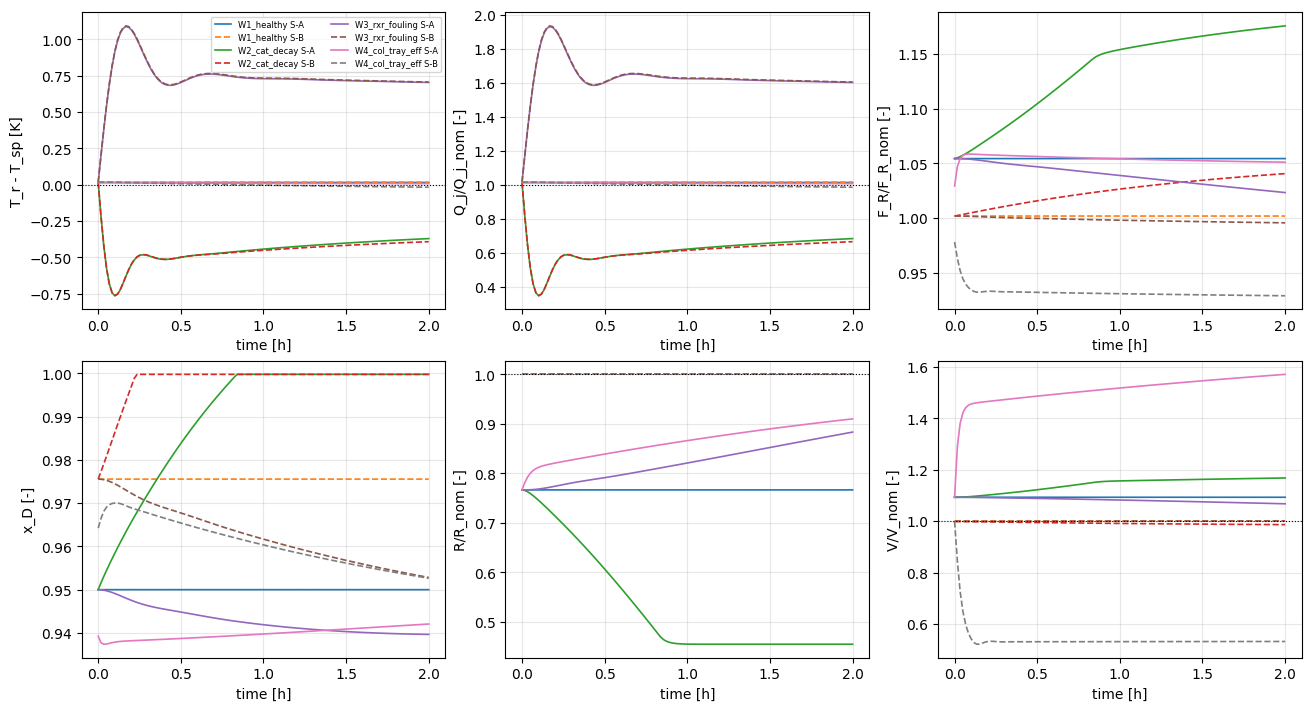

In [5]:
plot_specs = [
    ("T_r - T_sp [K]", "T_r", lambda y: y - T_SP),
    ("Q_j/Q_j_nom [-]", "Q_j", lambda y: y / QJ_NOM),
    ("F_R/F_R_nom [-]", "F_R_norm", lambda y: y),
    ("x_D [-]", "x_D", lambda y: y),
    ("R/R_nom [-]", "R_norm", lambda y: y),
    ("V/V_nom [-]", "V_norm", lambda y: y),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for key in SCENARIO_KEYS:
    for structure, ls in [("S-A", "-"), ("S-B", "--")]:
        case = cases[(key, structure)]
        raw = case["raw"]
        for ax, (ylabel, channel, transform) in zip(axes.ravel(), plot_specs):
            ax.plot(case["t"], transform(raw[:, RAW_INDEX[channel]]), ls=ls, lw=1.2, label=f"{key} {structure}")

for ax, (ylabel, _, _) in zip(axes.ravel(), plot_specs):
    ax.set_xlabel("time [h]")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
axes[0, 0].axhline(0.0, color="k", ls=":", lw=0.8)
axes[0, 1].axhline(1.0, color="k", ls=":", lw=0.8)
axes[1, 1].axhline(1.0, color="k", ls=":", lw=0.8)
axes[1, 2].axhline(1.0, color="k", ls=":", lw=0.8)
axes[0, 0].legend(fontsize=6, ncol=2)
plt.show()


## 6. Acceptance checks

In [6]:
def ch(case, name):
    return case["raw"][:, RAW_INDEX[name]]


w1_sa = cases[("W1_healthy", "S-A")]
w2_sb = cases[("W2_cat_decay", "S-B")]
w3_sb = cases[("W3_rxr_fouling", "S-B")]
w4_sa = cases[("W4_col_tray_eff", "S-A")]
w4_sb = cases[("W4_col_tray_eff", "S-B")]

snowball = 100.0 * (ch(w2_sb, "F_R_norm")[-1] / ch(w2_sb, "F_R_norm")[0] - 1.0)
masking = np.max(np.abs(ch(w3_sb, "T_r") - T_SP))
qj_change = 100.0 * (ch(w3_sb, "Q_j")[-1] / ch(w3_sb, "Q_j")[0] - 1.0)
r_shift = ch(w4_sa, "R_norm")[-1] - ch(w1_sa, "R_norm")[-1]
v_shift = ch(w4_sa, "V_norm")[-1] - ch(w1_sa, "V_norm")[-1]
structure_split = np.max(np.abs(ch(w4_sa, "x_D") - ch(w4_sb, "x_D")))
cl_excursion = np.max(np.abs(ch(w3_sb, "T_r") - T_SP))
ol_excursion = np.max(np.abs(ch(open_case, "T_r") - T_SP))

acceptance = pd.DataFrame([
    {
        "check": "S-A/S-B trajectories generated",
        "expected": "4 scenarios x 2 structures",
        "observed": len(cases),
        "status": "PASS" if len(cases) == 8 else "FAIL",
    },
    {
        "check": "explicit channel asymmetry",
        "expected": "S-A has x_D; S-B excludes x_D; both include R/V effort",
        "observed": f"S-A={len(SA_CHANNELS)}, S-B={len(SB_CHANNELS)}",
        "status": "PASS" if "x_D" in SA_CHANNELS and "x_D" not in SB_CHANNELS and "R_norm" in SB_CHANNELS else "FAIL",
    },
    {
        "check": "W1 closed-loop regulation",
        "expected": "healthy T_r near setpoint",
        "observed": f"S-A max |T_r-T_sp|={np.max(np.abs(ch(w1_sa, 'T_r') - T_SP)):.3f} K",
        "status": "PASS" if np.max(np.abs(ch(w1_sa, "T_r") - T_SP)) < 0.5 else "FAIL",
    },
    {
        "check": "W2 S-B snowball onset",
        "expected": "F_R increases",
        "observed": f"F_R change={snowball:.2f}%",
        "status": "PASS" if snowball > 3.0 else "FAIL",
    },
    {
        "check": "W3 temperature masking",
        "expected": "T_r nearly regulated despite fouling",
        "observed": f"max |T_r-T_sp|={masking:.3f} K",
        "status": "PASS" if masking < 2.0 else "FAIL",
    },
    {
        "check": "W3 compensation channel moves",
        "expected": "Q_j changes under fouling",
        "observed": f"Q_j change={qj_change:.2f}%",
        "status": "PASS" if abs(qj_change) > 5.0 else "FAIL",
    },
    {
        "check": "W4 S-A column compensation",
        "expected": "R or V moves under tray-efficiency loss",
        "observed": f"R shift={r_shift:.3f}, V shift={v_shift:.3f}",
        "status": "PASS" if max(abs(r_shift), abs(v_shift)) > 0.02 else "FAIL",
    },
    {
        "check": "S-A/S-B dynamic split",
        "expected": "W4 trajectories differ before measurement projection",
        "observed": f"max |x_D(S-A)-x_D(S-B)|={structure_split:.4f}",
        "status": "PASS" if structure_split > 1e-3 else "FAIL",
    },
    {
        "check": "closed-loop vs open-loop contrast",
        "expected": "open-loop W3 has larger T excursion",
        "observed": f"CL={cl_excursion:.2f} K, OL={ol_excursion:.2f} K",
        "status": "PASS" if ol_excursion > cl_excursion else "FAIL",
    },
])
acceptance


,check,expected,observed,status
0,S-A/S-B trajectories generated,4 scenarios x 2 structures,8,PASS
1,explicit channel asymmetry,S-A has x_D; S-B excludes x_D; both include R/...,"S-A=10, S-B=9",PASS
2,W1 closed-loop regulation,healthy T_r near setpoint,S-A max |T_r-T_sp|=0.015 K,PASS
3,W2 S-B snowball onset,F_R increases,F_R change=3.88%,PASS
4,W3 temperature masking,T_r nearly regulated despite fouling,max |T_r-T_sp|=1.093 K,PASS
5,W3 compensation channel moves,Q_j changes under fouling,Q_j change=58.08%,PASS
6,W4 S-A column compensation,R or V moves under tray-efficiency loss,"R shift=0.143, V shift=0.478",PASS
7,S-A/S-B dynamic split,W4 trajectories differ before measurement proj...,max |x_D(S-A)-x_D(S-B)|=0.0322,PASS
8,closed-loop vs open-loop contrast,open-loop W3 has larger T excursion,"CL=1.09 K, OL=118.91 K",PASS


## 7. Interpretation

The explicit-loop model passes the nb21 control-structure checks. S-A and S-B now
produce different trajectories under column degradation before any measurement
projection is applied. W2 preserves the recycle snowball onset, W3 preserves the
reactor-temperature masking mechanism, and W4 moves the reflux/boilup compensation
channels under the analyzer-rich structure.
